In [2]:
# from spin_sampler import Sampler , define_hopfield_model , initialize_spins
from configurations import load_data, make_params_dict, set_font_sizes, create_fig , apply_general_styles, save_fig
from configurations.plots import FONTSIZES
from binary_dimension import select_range, initial_gauss, LinearDistanceModel, DKL_Optimizer
import numpy as np
import matplotlib.pyplot as plt 
import time

apply_general_styles()

# Functions


In [3]:
def linear_regression_errors(x,y,sigmas):
    N = len(x)
    X = np.vstack([x,np.ones_like(x)]).T
    W = np.eye(N)/sigmas**2

    cov = np.linalg.inv(X.T@W@X)
    opt = cov@X.T@W@y
    return opt , np.sqrt(np.diag(cov))

# Plot gamma vs T

In [6]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 3
kl_perc = 80 

# Parameters fixed
N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
h = 0.9
rnd_ord = True
mode = 'single_chain'

# Parameters Lists
# temps = [0.6,0.9,1.2,1.5]
# Ns = [1024,2048,4096]
temps = np.linspace(0.4,1.6,25)#[::3]
# temps = [] #0.575, 0.59
temps = np.concatenate((temps, [0.56,1.19, 1.21]))
temps = np.sort(temps)
Ns = np.logspace(9,15,7,base=2).astype(int)[1:-1]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']

data = {}
for T in temps:
    data[T] = {'av':[], 'std':[]}
    for N in Ns:
        params = make_params_dict(name_fixed,names_variable)
        # print('-----------\n',f'Loading N={N}, T={T}...')
        dic = load_data('par',experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
        bid_pars = dic['bid_pars']
        sigmas = dic['sigmas']
        results = np.column_stack((bid_pars, sigmas))
        
        m = results.mean(axis=0)
        s = results.std(axis=0)
        m[0] /= N  # normalize by N
        s[0] /= N  # normalize by N
        # print(f'Loaded results for N={N}, T={T}, shape: {results},{m}, {s}')
        data[T]['av'].append(m)
        data[T]['std'].append(s)
    data[T]['av'] = np.array(data[T]['av'])
    data[T]['std'] = np.array(data[T]['std'])

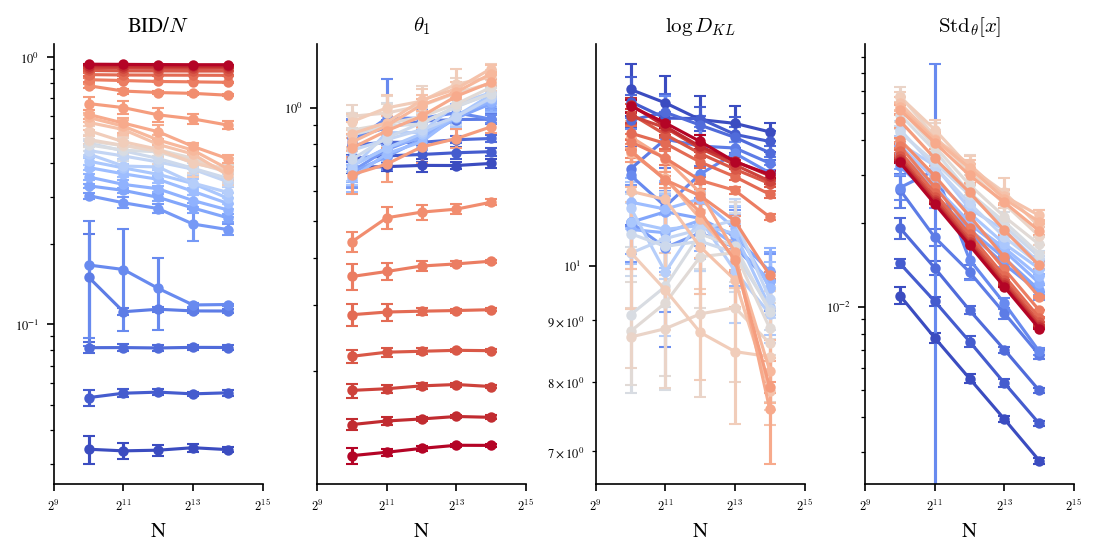

In [7]:
# Settings
set_font_sizes('tight')
titles = [r'BID/$N$',r'$\theta_1$',r'$\log D_{KL}$',r'$\text{Std}_\theta[x]$']
xtk = [2**k  for k in range(9,16,2)]
xlb = [fr'$2^{{{k}}}$' for k in range(9,16,2)]
colors = plt.get_cmap('coolwarm')(np.linspace(0,1,len(temps)))
# Create figure
fig , axes = create_fig(1,4,size='double')

for i , ax in enumerate(axes):
    for iT, T in enumerate(temps):
        av = np.abs(data[T]['av'][:,i])
        std = data[T]['std'][:,i]
        ax.errorbar(Ns, av, yerr=std, color=colors[iT], capsize=3, marker='o', markersize=4, linestyle='-',label=f'T={T:.2f}'   )
    ax.set_xscale('log', base=2)
    ax.set_xlim(left=xtk[0])
    ax.set_yscale('log')
    ax.set_xlabel('N')
    ax.set_title(titles[i])
    ax.set_xticks(xtk,xlb)
# ax.legend()


In [8]:
mean_gammas = [[],[]]
std_gammas = [[],[]]
for T in temps:
    for i , idx in enumerate([0,3]):
        m = data[T]['av'][:,idx]
        s = data[T]['std'][:,idx]
        a1 , b1 = (linear_regression_errors(np.log(Ns),np.log(m),s/m))
        # Store mean and std of scaling exponent
        mean_gammas[i].append(-a1[0])
        std_gammas[i].append(b1[0])
mean_gammas = np.array(mean_gammas)
std_gammas = np.array(std_gammas)
print(mean_gammas.shape)
print(std_gammas.shape)    

(2, 28)
(2, 28)


Figure saved on c:\Users\crise\OneDrive - SISSA\Documents\REPOS\Hopfield_Dimensionality\plots as scaling_exponents_vs_T_N_samples10000_a_max0.3_a_min0.001_alpha0.04_h0.9_kl_perc80_modesingle_chain_z_threshold3.png


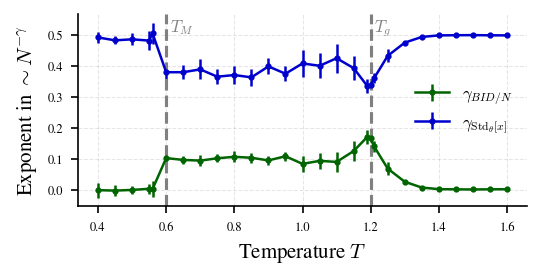

In [12]:
# Settings
set_font_sizes('tight')
labels = [r'$\gamma_{BID/N}$',r'$\gamma_{\text{Std}_\theta[x]}$']
colors = ['darkgreen','mediumblue']
# Create figure
fig , axes = create_fig(1,1,size='single')
ax = axes
for i , lb in enumerate(labels):
    ax.errorbar(temps, mean_gammas[i], yerr=std_gammas[i], color=colors[i], capsize=0, marker='o', markersize=2, lw=1.2,linestyle='-',label=lb)
    # ax.plot(temps,std_gammas[i], color=colors[i], marker='o', markersize=4, linestyle='-',label=lb)
    ax.set_xlabel(r'Temperature $T$')
ax.set_ylabel(r'Exponent in $\sim N^{-\gamma}$')

for lbT , Tc in zip([r'$T_M$',r'$T_g$'],[0.6,1.2]):
    ax.axvline(Tc,color='gray',linestyle='--')
    ax.text(Tc+0.01,ax.get_ylim()[1]*0.9,lbT,color='gray')

ax.grid(lw=0.5,c='k',alpha=0.1,ls='--')

Tnew =  [0.9,1.2,1.5] #(2, 4)
col = 'brown'
# ax.errorbar(Tnew, mean_gammas_m[0], yerr=std_gammas_m[0], color=col, capsize=2, marker='s', markersize=1, lw=1,ls=' ',label=r'Multi-chain')
# ax.errorbar(Tnew, mean_gammas_m[1], yerr=std_gammas_m[1], color=col, capsize=2, marker='s', markersize=1, lw=1,ls=' ')
ax.legend(frameon=False,fontsize=FONTSIZES['s'])

names = ['N_samples','alpha','h','mode','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
save_fig(fig, 'scaling_exponents_vs_T',params=params)

# Compare single vs multi chain

In [21]:
# Parse arguments
a_min = 1e-3
a_max = 0.3
z_threshold = 2
kl_perc = 80 

# Parameters fixed
# N_samples = 10000
dt_samples = 1
burnin = 800
alpha = 0.04
# h = 0.9
rnd_ord = True
modes = ['single_chain', 'multi_chain']

# Parameters Lists
temps = [0.9,1.2,1.5]
Ns = [1024,2048,4096]

# Parameters to save
names_variable = ['T','N']
name_fixed = ['N_samples','dt_samples','burnin','alpha','h','rnd_ord','mode','a_min','a_max','z_threshold','kl_perc']

data = {}
for mode in modes:
    data[mode] = {}
    if mode == 'single_chain':
        N_samples = 10000
        h = 0.9
        txt = 'bid_parms'
    else:
        N_samples = 3500
        h = 0.0
        txt = 'bid_parameters'
    for T in temps:
        data[mode][T] = {'av':[], 'std':[]}
        for N in Ns:
            params = make_params_dict(name_fixed,names_variable)
            # print('-----------\n',f'Loading N={N}, T={T}...')
            dic = load_data(txt,experiment_name= 'scaling_exponents_filtered', params=params,base_dir='..\\data',show=False)
            bid_pars = dic['bid_pars']
            sigmas = dic['sigmas']
            results = np.column_stack((bid_pars, sigmas))
            m = results.mean(axis=0)
            s = results.std(axis=0)
            m[0] /= N  # normalize by N
            s[0] /= N  # normalize by N
            data[mode][T]['av'].append(m)
            data[mode][T]['std'].append(s)
        data[mode][T]['av'] = np.array(data[mode][T]['av'])
        data[mode][T]['std'] = np.array(data[mode][T]['std'])

Figure saved on c:\Users\crise\OneDrive - SISSA\Documents\REPOS\Hopfield_Dimensionality\plots as params_vs_N_N_samples3500_a_max0.3_a_min0.001_alpha0.04_h0_kl_perc80_z_threshold2.png


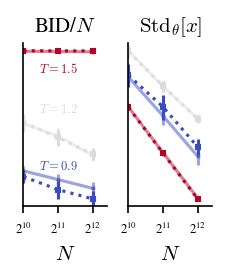

In [79]:
# Settings
set_font_sizes('tight')
titles = [r'BID/$N$',r'$\theta_1$',r'$\log D_{KL}$',r'$\text{Std}_\theta[x]$']
idx = [0,3] 
# xtk = [2**k  for k in range(9,16,2)]
# xlb = [fr'$2^{{{k}}}$' for k in range(9,16,2)]
colors = plt.get_cmap('coolwarm')(np.linspace(0,1,len(temps)))
# Create figure
fig , axes = create_fig(1,2,size='single',w=0.4,h=0.5)

for i , ax in enumerate(axes):

    ax.set_xscale('log', base=2)
    ax.set_yscale('log')
    ax.set_title(titles[idx[i]])
    ax.set_xlabel(r'$N$')
    # Remove all y-axis ticks and labels (major and minor)
    # ax.set_yticks([])
    ax.set_yticks([], minor=True)
    # ax.set_yticklabels([])
    # Ensure no visible tick marks for y-axis
    # ax.tick_params(axis='y', which='both', length=0, labelsize=FONTSIZES['xxs'])

    for iT, T in enumerate(temps):
        if i == 0:
            ax.text(2048, [0.25,0.6,0.85][iT], rf'$T={T}$', color=colors[iT], fontsize=FONTSIZES['xs'], va='center', ha='center',transform=ax.get_xaxis_transform())
        for im , mode in enumerate(modes):
            av = np.abs(data[mode][T]['av'][:,idx[i]])
            std = data[mode][T]['std'][:,idx[i]]
            ax.errorbar(Ns, av, yerr=std, color=colors[iT], capsize=0, marker=['.','s'][im], markersize=2, alpha=[0.5,1.0][im],linestyle=['-',':'][im],label=rf'$T={T}$')
    ax.set_xlim(left=Ns[0])

names = ['N_samples','alpha','h','a_min','a_max','z_threshold','kl_perc']
params = make_params_dict(names)
save_fig(fig, 'params_vs_N',params=params)


In [70]:
mean_gammas_m = [[],[]]
std_gammas_m = [[],[]]
for T in temps:
    for i , idx in enumerate([0,3]):
        m = data['single_chain'][T]['av'][:,idx]
        s = data['single_chain'][T]['std'][:,idx]
        a1 , b1 = (linear_regression_errors(np.log(Ns),np.log(m),s/m))
        # Store mean and std of scaling exponent
        mean_gammas_m[i].append(-a1[0])
        std_gammas_m[i].append(b1[0])
mean_gammas_m = np.array(mean_gammas_m)
std_gammas_m = np.array(std_gammas_m)
print(mean_gammas_m.shape)
print(std_gammas_m.shape)    

(2, 3)
(2, 3)


In [71]:
print("For mode 'multi_chain':")
for iT , T in enumerate(temps):
    print(f"T={T}" )
    print(f"  BID/N exponent: {mean_gammas_m[0][iT]:.4f} +/- {std_gammas_m[0][iT]:.4f}")
    print(f"  Std_theta[x] exponent: {mean_gammas_m[1][iT]:.4f} +/- {std_gammas_m[1][iT]:.4f}")
# mean_gammas_m

For mode 'multi_chain':
T=0.9
  BID/N exponent: 0.0746 +/- 0.0356
  Std_theta[x] exponent: 0.4318 +/- 0.0666
T=1.2
  BID/N exponent: 0.1363 +/- 0.0370
  Std_theta[x] exponent: 0.3683 +/- 0.0323
T=1.5
  BID/N exponent: 0.0025 +/- 0.0023
  Std_theta[x] exponent: 0.4978 +/- 0.0023
